# RQ3: What kinds of pull requests contain the most proficient code?

Re-analysis of RQ3 on the CPET-era data with task-type labels attached, for all three comparison groups.

**Inputs** (same column layout, one row per PR, `A1`..`C2` are construct counts):

| file | group | rows | task-type labels from |
|---|---|---|---|
| `analysis/rq3_agent_prs_with_task_type.csv` | AI agents | 491 | AIDev `pr_task_type.parquet` |
| `analysis/rq3_human_prs_with_task_type.csv` | Human (post-ChatGPT) | 513 | AIDev `human_pr_task_type.parquet` |
| `analysis/rq3_pre_chatgpt_prs_with_task_type.csv` | Human (pre-ChatGPT) | 477 | GPT-4.1-mini, see `rq3_labelling_prompt.md` |

**What the notebook does**

1. Loads and sanity-checks the three files.
2. Task-type distribution per group.
3. **Part 1 (paper's RQ3 method):** IQR outliers on the per-PR C1 + C2 count, task types of the outlier PRs, bubble plot (log scale). First for agents (replaces Figure `fig:action_impact`), then for the two human groups.
4. **Part 2 (all PRs, not only outliers):** proficiency by task type within each group, Kruskal–Wallis across task types, task type versus agent identity, and group differences within each task type.
5. Figures and LaTeX tables written to disk.

**Outputs**: figures go to the repository root (where `paper.tex` includes them by filename) under new names, `rq3_*.pdf/png`, so the existing `action_impact_*.pdf` files are left untouched until you swap the `\includegraphics` lines. Tables go to `analysis/rq3_tables/`.

Run from the `analysis/` folder (or the repository root) with the project venv: `.venv/bin/python -m ipykernel` / Jupyter.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import ScalarFormatter, FixedLocator
from scipy import stats

# Locate the package root (the folder holding data/ and README.md) by walking up from
# the working directory, so this notebook runs from its own folder or from the root.
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, 'data'))
           and os.path.exists(os.path.join(ROOT, 'README.md'))):
    _parent = os.path.dirname(ROOT)
    if _parent == ROOT:
        raise RuntimeError('could not locate the package root from ' + os.getcwd())
    ROOT = _parent

DATA = os.path.join(ROOT, 'data')                # shared per-PR tables
RQ_DIR = os.path.join(ROOT, 'rq3')              # this notebook's own folder
FIG_DIR = os.path.join(RQ_DIR, 'figures')
TAB_DIR = os.path.join(RQ_DIR, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

LEVELS = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
GROUPS = ['AI agents', 'Human', 'Human (pre-ChatGPT)']
SHORT = {'AI agents': 'agents', 'Human': 'human', 'Human (pre-ChatGPT)': 'pre_chatgpt'}
TASKS = ['build', 'chore', 'ci', 'docs', 'feat', 'fix', 'other', 'perf', 'refactor', 'style', 'test']
AGENTS = ['Copilot', 'Devin', 'Cursor']
FILES = {
    'AI agents':           'rq3_agent_prs_with_task_type.csv',
    'Human':               'rq3_human_prs_with_task_type.csv',
    'Human (pre-ChatGPT)': 'rq3_pre_chatgpt_prs_with_task_type.csv',
}
MIN_N = 10   # a task type needs at least this many PRs in a group to enter a test

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('package root:', os.path.basename(ROOT))

package root: agent-cefr-journal-study


## 1. Load and sanity-check the data

In [2]:
frames = []
for g, f in FILES.items():
    d = pd.read_csv(os.path.join(DATA, f), dtype={'pr_id': str})
    assert (d['group'] == g).all(), f'{f}: unexpected group label'
    frames.append(d)
df = pd.concat(frames, ignore_index=True)
df['group'] = pd.Categorical(df['group'], categories=GROUPS, ordered=True)

# Consistency of the derived columns shipped in the CSVs.
assert df['pr_id'].is_unique
assert df['type'].isin(TASKS).all(), sorted(set(df['type']) - set(TASKS))
assert (df[LEVELS].sum(axis=1) == df['total']).all()
assert ((df['C1'] + df['C2']) == df['c1c2']).all()
ordinal = (df[LEVELS] * np.arange(1, 7)).sum(axis=1) / df['total']
assert np.allclose(ordinal, df['cefr_mean'], atol=1e-3)
assert np.allclose(100 * df['c1c2'] / df['total'], df['c1c2_pct'], atol=1e-3)

print(df.groupby('group', observed=True).size().rename('PRs').to_frame().T)
print('\nrepositories per group:')
print(df.groupby('group', observed=True)['repo'].nunique().to_frame().T)
print('\nagents (AI agents group only):', df.loc[df.group == 'AI agents', 'agent'].value_counts().to_dict())
print('\n`confidence` is only populated for the agent and pre-ChatGPT groups (AIDev left it NULL for humans),')
print('so it is not used as a filter anywhere in this notebook:')
print(df.groupby('group', observed=True)['confidence'].apply(lambda s: s.notna().mean()).rename('share populated').to_frame().T)

group  AI agents  Human  Human (pre-ChatGPT)
PRs          481    537                  465

repositories per group:
group  AI agents  Human  Human (pre-ChatGPT)
repo         130    135                   49

agents (AI agents group only): {'Devin': 202, 'Copilot': 184, 'Cursor': 95}

`confidence` is only populated for the agent and pre-ChatGPT groups (AIDev left it NULL for humans),
so it is not used as a filter anywhere in this notebook:
group            AI agents  Human  Human (pre-ChatGPT)
share populated      1.000  0.000                1.000


## 2. Task-type distribution per group

In [3]:
counts = pd.crosstab(df['type'], df['group']).reindex(TASKS).fillna(0).astype(int)
pct = counts.div(counts.sum(axis=0), axis=1) * 100
dist = pd.concat({'n PRs': counts, '% of group': pct.round(1)}, axis=1)
dist = dist.loc[counts.sum(axis=1).sort_values(ascending=False).index]
dist

n PRs                           % of group                           
group    AI agents Human Human (pre-ChatGPT)  AI agents  Human Human (pre-ChatGPT)
type                                                                              
feat           231   257                 120     48.000 47.900              25.800
fix            163   175                 167     33.900 32.600              35.900
refactor        35    37                  36      7.300  6.900               7.700
test            21    18                  35      4.400  3.400               7.500
docs            15    14                  16      3.100  2.600               3.400
chore            4    15                  25      0.800  2.800               5.400
perf             3     8                  21      0.600  1.500               4.500
other            1     7                  21      0.200  1.300               4.500
ci               3     2                  11      0.600  0.400               2.400
build            4     2                   6      0.800  0.400               1.300
style            1     2                   7      0.200  0.400               1.500

In [4]:
# Chi-square: is the task-type mix different across the three groups?
chi2, p, dof, _ = stats.chi2_contingency(counts.T.values)
n = counts.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(counts.shape) - 1)))
print(f'task type x group: chi2 = {chi2:.2f}, df = {dof}, p = {p:.3g}, Cramér\'s V = {cramers_v:.3f}')

task type x group: chi2 = 128.39, df = 20, p = 7.82e-18, Cramér's V = 0.208


## 3. Part 1: the paper's RQ3 method (IQR outliers on C1 + C2)

The paper identifies PRs that introduce unusually many C1 + C2 constructs, using the IQR rule (C1 + C2 $> Q_3 + 1.5 \times IQR$), and then looks at the task types of those PRs.

For reference, the numbers currently in the paper (pycefr-era data, agents only) are: 61 outlier PRs, C1 + C2 from 13 to 483, median 25, mean 58.44, and eight task types on the figure (feat 36 PRs / 1,510 constructs, fix 9 / 902, refactor 9 / 506, test 5 / 204, build 1 / 224, chore 1 / 219, plus docs and perf with one PR each).

In [5]:
def iqr_outliers(d, col='c1c2'):
    q1, q3 = d[col].quantile([0.25, 0.75])
    thr = q3 + 1.5 * (q3 - q1)
    return d[d[col] > thr].copy(), thr


def outlier_report(d):
    out, thr = iqr_outliers(d)
    summary = pd.Series({
        'PRs in group': len(d), 'threshold (Q3 + 1.5 IQR)': thr, 'outlier PRs': len(out),
        '% of group': 100 * len(out) / len(d),
        'min C1+C2': out['c1c2'].min(), 'max C1+C2': out['c1c2'].max(),
        'median C1+C2': out['c1c2'].median(), 'mean C1+C2': out['c1c2'].mean(),
        'repositories': out['repo'].nunique(),
    })
    per_task = (out.groupby('type')
                   .agg(n_prs=('pr_id', 'size'), total_c1c2=('c1c2', 'sum'),
                        mean_c1c2=('c1c2', 'mean'), median_c1c2=('c1c2', 'median'),
                        n_repos=('repo', 'nunique'))
                   .sort_values(['n_prs', 'total_c1c2'], ascending=False))
    return out, summary, per_task


agent_out, agent_summary, agent_per_task = outlier_report(df[df.group == 'AI agents'])
print(agent_summary.to_string())
print()
print(agent_per_task)

PRs in group               481.000
threshold (Q3 + 1.5 IQR)    10.000
outlier PRs                 47.000
% of group                   9.771
min C1+C2                   11.000
max C1+C2                  609.000
median C1+C2                24.000
mean C1+C2                  71.319
repositories                31.000

          n_prs  total_c1c2  mean_c1c2  median_c1c2  n_repos
type                                                        
feat         27        1055     39.074       24.000       19
refactor      7         483     69.000       17.000        7
test          6         216     36.000       24.000        3
fix           5         972    194.400       25.000        4
chore         1         318    318.000      318.000        1
build         1         308    308.000      308.000        1


In [6]:
# Which agent wrote the outlier PRs, and does the per-agent share differ from the whole agent sample?
share = pd.concat({
    'all agent PRs': df[df.group == 'AI agents']['agent'].value_counts(normalize=True) * 100,
    'outlier PRs':   agent_out['agent'].value_counts(normalize=True) * 100,
}, axis=1).round(1)
share.index.name = 'agent'
print(share)
print()
print(pd.crosstab(agent_out['type'], agent_out['agent']).reindex(columns=AGENTS, fill_value=0))

         all agent PRs  outlier PRs
agent                              
Devin           42.000       31.900
Copilot         38.300       44.700
Cursor          19.800       23.400

agent     Copilot  Devin  Cursor
type                            
build           1      0       0
chore           1      0       0
feat           13      8       6
fix             4      1       0
refactor        2      2       3
test            0      4       2


### Bubble plot (Figure `fig:action_impact`): task types of the outlier PRs

wrote rq3/figures/rq3_outlier_tasks_agents.{pdf,png}


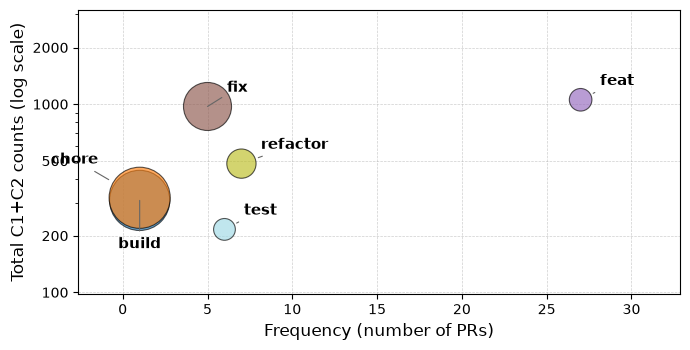

In [7]:
# One fixed colour per task type so the three groups' figures are comparable.
TASK_COLOR = dict(zip(TASKS, plt.cm.tab20(np.linspace(0, 1, len(TASKS)))))
LOG_TICKS = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]


# Candidate label offsets in points, tried in order until a label neither overlaps a
# previously placed label nor another bubble: right, left, above, below, then farther out.
LABEL_OFFSETS = [(14, 8, 'left'), (-14, 8, 'right'), (14, -16, 'left'), (-14, -16, 'right'),
                 (0, 22, 'center'), (0, -26, 'center'), (30, 22, 'left'), (-30, 22, 'right'),
                 (30, -30, 'left'), (-30, -30, 'right'), (0, 40, 'center'), (0, -44, 'center')]


def _overlap(a, b):
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


def place_labels(ax, pt, sizes, fontsize=11):
    # Annotate each bubble, staggering labels so that co-located bubbles stay readable.
    fig = ax.figure
    to_pt = 72.0 / fig.dpi                                   # display pixels -> points
    centres = {t: ax.transData.transform((r['n_prs'], r['total_c1c2'])) * to_pt for t, r in pt.iterrows()}
    radii = {t: np.sqrt(s / np.pi) for t, s in zip(pt.index, sizes)}
    bubbles = [(c[0] - radii[t], c[1] - radii[t], c[0] + radii[t], c[1] + radii[t]) for t, c in centres.items()]
    placed = []
    for t, row in pt.iterrows():
        cx, cy = centres[t]
        w, h = 0.62 * fontsize * len(t), 1.15 * fontsize
        chosen = LABEL_OFFSETS[0]
        for dx, dy, ha in LABEL_OFFSETS:
            x0 = cx + dx - (w if ha == 'right' else w / 2 if ha == 'center' else 0)
            y0 = cy + dy - (h if dy < 0 else 0)
            box = (x0, y0, x0 + w, y0 + h)
            others = [b for k, b in zip(centres, bubbles) if k != t]
            if not any(_overlap(box, p) for p in placed) and not any(_overlap(box, b) for b in others):
                chosen = (dx, dy, ha)
                break
        dx, dy, ha = chosen
        x0 = cx + dx - (w if ha == 'right' else w / 2 if ha == 'center' else 0)
        y0 = cy + dy - (h if dy < 0 else 0)
        placed.append((x0, y0, x0 + w, y0 + h))
        ax.annotate(t, (row['n_prs'], row['total_c1c2']), xytext=(dx, dy), textcoords='offset points',
                    ha=ha, va='bottom' if dy >= 0 else 'top', fontsize=fontsize, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color='0.4', lw=0.8, shrinkB=radii[t] + 1), zorder=4)


def bubble_plot(per_task, out_stem=None, title=None, ax=None, size_scale=6.0):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.0, 3.6))
    pt = per_task.sort_values(['n_prs', 'total_c1c2'])
    sizes = 30 + size_scale * pt['mean_c1c2'].values
    ax.scatter(pt['n_prs'], pt['total_c1c2'], s=sizes,
               c=[TASK_COLOR[t] for t in pt.index], alpha=0.65, edgecolor='black', linewidth=0.8,
               zorder=3)
    ax.set_yscale('log')
    lo, hi = pt['total_c1c2'].min(), pt['total_c1c2'].max()
    ax.set_ylim(lo / 2.2, hi * 3)
    ticks = [t for t in LOG_TICKS if lo / 2.2 <= t <= hi * 3]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlim(-0.06 * pt['n_prs'].max() - 1, pt['n_prs'].max() * 1.18 + 1)
    ax.set_xlabel('Frequency (number of PRs)', fontsize=12)
    ax.set_ylabel('Total C1+C2 counts (log scale)', fontsize=12)
    ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.6)
    if title:
        ax.set_title(title, fontsize=12)
    if own_fig:
        fig.tight_layout()
    place_labels(ax, pt, sizes)          # after limits and layout, so data->points is final
    if own_fig:
        if out_stem:
            for ext in ('pdf', 'png'):
                fig.savefig(os.path.join(FIG_DIR, f'{out_stem}.{ext}'), bbox_inches='tight',
                            dpi=200 if ext == 'png' else None)
            print('wrote', os.path.relpath(os.path.join(FIG_DIR, out_stem + '.{pdf,png}'), ROOT))
        return fig, ax
    return ax


fig, ax = bubble_plot(agent_per_task, out_stem='rq3_outlier_tasks_agents')
plt.show()

### The same outlier analysis for the two human groups

In [8]:
reports = {'AI agents': (agent_out, agent_summary, agent_per_task)}
for g in GROUPS[1:]:
    reports[g] = outlier_report(df[df.group == g])

summary_all = pd.DataFrame({g: r[1] for g, r in reports.items()})
summary_all

,AI agents,Human,Human (pre-ChatGPT)
PRs in group,481.000,537.000,465.000
threshold (Q3 + 1.5 IQR),10.000,7.500,5.000
outlier PRs,47.000,79.000,65.000
% of group,9.771,14.711,13.978
min C1+C2,11.000,8.000,6.000
max C1+C2,609.000,244.000,208.000
median C1+C2,24.000,17.000,15.000
mean C1+C2,71.319,28.886,32.308
repositories,31.000,34.000,26.000


In [9]:
per_task_all = pd.concat({g: r[2] for g, r in reports.items()}, axis=1).reindex(TASKS).dropna(how='all')
per_task_all = per_task_all.loc[per_task_all.xs('n_prs', axis=1, level=1).fillna(0).sum(axis=1).sort_values(ascending=False).index]
per_task_all

AI agents                                           Human                                          Human (pre-ChatGPT)                                         
             n_prs total_c1c2 mean_c1c2 median_c1c2 n_repos  n_prs total_c1c2 mean_c1c2 median_c1c2 n_repos               n_prs total_c1c2 mean_c1c2 median_c1c2 n_repos
type                                                                                                                                                                    
feat        27.000  1,055.000    39.074      24.000  19.000 58.000  1,419.000    24.466      16.500  26.000              25.000    724.000    28.960      17.000  17.000
fix          5.000    972.000   194.400      25.000   4.000  6.000    240.000    40.000      21.000   6.000              12.000    393.000    32.750      15.000   9.000
refactor     7.000    483.000    69.000      17.000   7.000  4.000    114.000    28.500      30.500   4.000               5.000     65.000    13.000       9.000   5.000
test         6.000    216.000    36.000      24.000   3.000  4.000    283.000    70.750      15.000   4.000               5.000    144.000    28.800      13.000   5.000
other          NaN        NaN       NaN         NaN     NaN  2.000     42.000    21.000      21.000   2.000               7.000    305.000    43.571      13.000   4.000
chore        1.000    318.000   318.000     318.000   1.000  2.000     43.000    21.500      21.500   2.000               4.000    188.000    47.000      17.500   3.000
docs           NaN        NaN       NaN         NaN     NaN  3.000    141.000    47.000      17.000   2.000               1.000     14.000    14.000      14.000   1.000
build        1.000    308.000   308.000     308.000   1.000    NaN        NaN       NaN         NaN     NaN               2.000    225.000   112.500     112.500   1.000
perf           NaN        NaN       NaN         NaN     NaN    NaN        NaN       NaN         NaN     NaN               3.000     27.000     9.000      10.000   2.000
ci             NaN        NaN       NaN         NaN     NaN    NaN        NaN       NaN         NaN     NaN               1.000     15.000    15.000      15.000   1.000

wrote rq3/figures/rq3_outlier_tasks_human.{pdf,png}


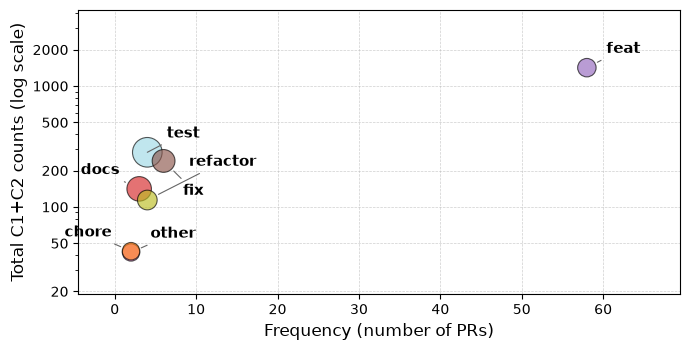

wrote rq3/figures/rq3_outlier_tasks_pre_chatgpt.{pdf,png}


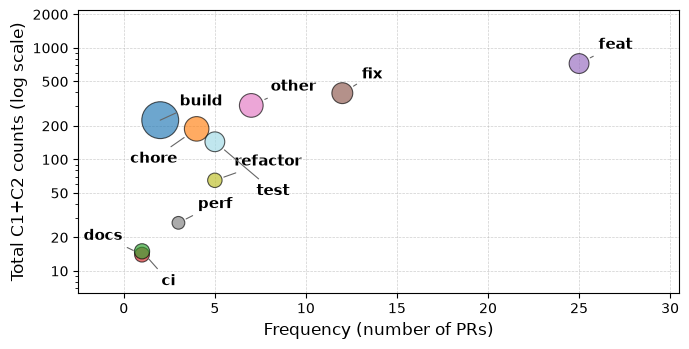

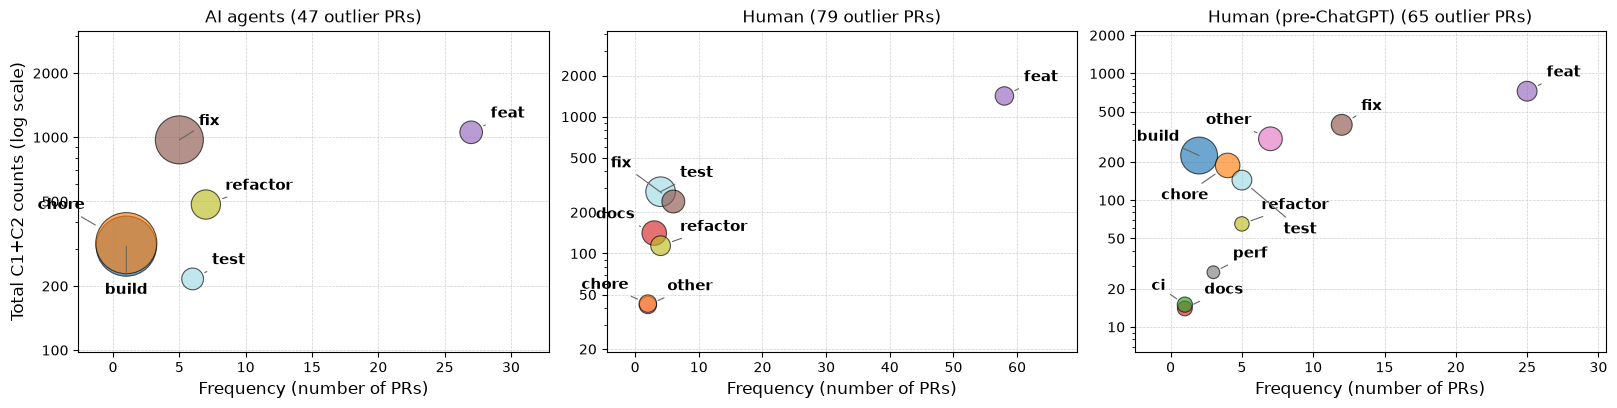

In [10]:
# Per-group figures (one file each) and a combined three-panel figure.
for g in GROUPS[1:]:
    bubble_plot(reports[g][2], out_stem=f'rq3_outlier_tasks_{SHORT[g]}')
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
fig.tight_layout()                      # fix the axes geometry before labels are placed
for ax, g in zip(axes, GROUPS):
    bubble_plot(reports[g][2], ax=ax, title=f'{g} ({int(reports[g][1]["outlier PRs"])} outlier PRs)')
for ax in axes[1:]:
    ax.set_ylabel('')
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIG_DIR, f'rq3_outlier_tasks_all_groups.{ext}'), bbox_inches='tight',
                dpi=200 if ext == 'png' else None)
plt.show()

In [11]:
# Outlier PRs for manual inspection (title, URL, task type, counts).
outliers = pd.concat([r[0] for r in reports.values()])
cols = ['group', 'pr_id', 'repo', 'agent', 'type', 'confidence', 'c1c2', 'c1c2_pct', 'total', 'cefr_mean',
        'additions', 'deletions', 'changed_files', 'title', 'html_url']
outliers[cols].sort_values(['group', 'c1c2'], ascending=[True, False]).to_csv(
    os.path.join(DATA, 'rq3_outlier_prs.csv'), index=False)
print(len(outliers), 'outlier PRs written to analysis/rq3_outlier_prs.csv')
outliers[cols].sort_values('c1c2', ascending=False).head(15)

191 outlier PRs written to analysis/rq3_outlier_prs.csv


,group,pr_id,repo,agent,type,confidence,c1c2,c1c2_pct,total,cefr_mean,additions,deletions,changed_files,title,html_url
439,AI agents,3244675358,Azure-Samples/openai-chat-vision-quickstart,Copilot,fix,10.000,609,3.339,18241,1.664,4.000,4.000,2.000,Fix h11 dependency upgrade from 0.14.0 to 0.16...,https://github.com/Azure-Samples/openai-chat-v...
389,AI agents,3223709587,allthingslinux/tux,Cursor,refactor,10.000,381,3.318,11481,1.737,761.000,545.000,146.000,Refactor project structure for modularity,https://github.com/allthingslinux/tux/pull/944
246,AI agents,3152257828,microsoft/typespec,Copilot,chore,9.000,318,3.334,9538,1.671,13.000,5.000,3.000,[python] Upgrade TCGC 0.57.1 for http-client-p...,https://github.com/microsoft/typespec/pull/7667
438,AI agents,3244675240,Azure-Samples/openai-chat-vision-quickstart,Copilot,fix,10.000,308,3.413,9024,1.683,4.000,2.000,2.000,Fix dependency conflict: update aiosignal to 1...,https://github.com/Azure-Samples/openai-chat-v...
234,AI agents,3147157841,remotion-dev/remotion,Copilot,build,9.000,308,3.413,9024,1.683,5.000,1.000,2.000,Update boto3 version constraint to support lat...,https://github.com/remotion-dev/remotion/pull/...
976,Human,2580095745,awslabs/mcp,NaN,test,NaN,244,5.083,4800,1.898,"10,373.000","5,395.000",34.000,test(ecs-mcp-server): Upgrade test coverage fo...,https://github.com/awslabs/mcp/pull/560
100,AI agents,2925357207,disler/single-file-agents,Devin,feat,9.000,213,7.648,2785,1.794,"5,131.000",0.000,49.000,Add codebase architectures examples,https://github.com/disler/single-file-agents/p...
1354,Human (pre-ChatGPT),1464102540,Azure/azure-sdk-for-python,NaN,other,7.000,208,3.181,6539,1.538,"13,670.000","3,029.000",81.000,[AutoRelease] t2-azurestackhci-2022-11-25-0482...,https://github.com/Azure/azure-sdk-for-python/...
1235,Human (pre-ChatGPT),1445100121,onnx/onnx,NaN,fix,9.000,183,1.706,10727,1.589,3.000,3.000,1.000,Fix _parse_repo_info,https://github.com/onnx/onnx/pull/4648
1224,Human (pre-ChatGPT),1440724171,InamuraJIN/ActionRecorder,NaN,feat,8.000,151,3.919,3853,1.596,"9,311.000","3,765.000",91.000,Update to Version 4.0.0,https://github.com/InamuraJIN/ActionRecorder/p...


## 4. Part 2: proficiency by task type over all PRs

The outlier view only looks at the tail. Here every PR contributes, and proficiency is measured in two ways:

* **construct share**: the share of C1 + C2 among all constructs of a (group, task type) cell, pooled over PRs (dominated by large PRs), and
* **per-PR**: the ordinal CEFR mean (`cefr_mean`, A1 = 1 … C2 = 6) and the per-PR share of C1 + C2 (`c1c2_pct`), reported as medians so every PR counts once.

In [12]:
def task_profile(d):
    g = d.groupby('type')
    lv = g[LEVELS].sum()
    prof = pd.DataFrame({
        'n_prs': g.size(),
        'constructs': lv.sum(axis=1),
        'C1+C2 share %': 100 * (lv['C1'] + lv['C2']) / lv.sum(axis=1),
        'median cefr_mean': g['cefr_mean'].median(),
        'mean cefr_mean': g['cefr_mean'].mean(),
        'median c1c2_pct': g['c1c2_pct'].median(),
        'median C1+C2 per PR': g['c1c2'].median(),
    })
    return prof.reindex(TASKS).dropna(subset=['n_prs'])


profiles = {g: task_profile(df[df.group == g]) for g in GROUPS}
for g in GROUPS:
    print(f'=== {g} ===')
    print(profiles[g].sort_values('n_prs', ascending=False).round(3))
    print()

=== AI agents ===
          n_prs  constructs  C1+C2 share %  median cefr_mean  mean cefr_mean  median c1c2_pct  median C1+C2 per PR
type                                                                                                              
feat        231       38372          3.906             1.591           1.650            1.379                1.000
fix         163       38318          3.059             1.623           1.640            0.000                0.000
refactor     35       15537          3.366             1.880           2.025            0.616                1.000
test         21        6304          4.521             1.961           2.006            3.668                6.000
docs         15         899          3.560             1.392           1.596            0.000                0.000
build         4        9065          3.409             1.068           1.205            1.351                0.500
chore         4        9590          3.358             2.287  

In [13]:
# Compact comparison table: per-PR median CEFR mean and pooled C1+C2 share, task type x group.
compact = pd.concat({
    'n PRs':            pd.DataFrame({g: profiles[g]['n_prs'] for g in GROUPS}),
    'median cefr_mean': pd.DataFrame({g: profiles[g]['median cefr_mean'] for g in GROUPS}),
    'C1+C2 share %':    pd.DataFrame({g: profiles[g]['C1+C2 share %'] for g in GROUPS}),
}, axis=1).reindex(TASKS)
compact = compact.loc[compact['n PRs'].fillna(0).sum(axis=1).sort_values(ascending=False).index]
compact.round(2)

n PRs                           median cefr_mean                           C1+C2 share %                          
         AI agents Human Human (pre-ChatGPT)        AI agents Human Human (pre-ChatGPT)     AI agents Human Human (pre-ChatGPT)
type                                                                                                                           
feat           231   257                 120            1.590 1.710               1.700         3.910 3.240               4.440
fix            163   175                 167            1.620 1.620               1.590         3.060 3.280               2.560
refactor        35    37                  36            1.880 1.690               2.000         3.370 2.690               3.810
test            21    18                  35            1.960 1.890               1.770         4.520 4.790               2.990
docs            15    14                  16            1.390 1.740               1.450         3.560 2.590               2.790
chore            4    15                  25            2.290 1.700               1.710         3.360 3.390               4.210
perf             3     8                  21            1.860 1.480               1.680         1.590 2.670               2.680
other            1     7                  21            1.670 1.930               1.770         0.000 9.160               3.610
ci               3     2                  11            1.770 1.820               1.330         1.020 0.000               1.760
build            4     2                   6            1.070 1.670               1.550         3.410 1.860               5.130
style            1     2                   7            1.000 1.240               1.330         0.000 1.610               1.160

### Statistics helpers

In [14]:
def kruskal_by(d, by, value='cefr_mean', min_n=MIN_N):
    # Kruskal-Wallis across the levels of `by` with at least `min_n` PRs, plus epsilon-squared.
    sizes = d.groupby(by, observed=True).size()
    keep = sizes[sizes >= min_n].index
    samples = [d.loc[d[by] == k, value].values for k in keep]
    if len(samples) < 2:
        return dict(levels=list(keep), k=len(keep), n=int(sizes[keep].sum()), H=np.nan, p=np.nan, eps2=np.nan)
    H, p = stats.kruskal(*samples)
    n, k = sum(len(s) for s in samples), len(samples)
    eps2 = (H - k + 1) / (n - k)          # epsilon-squared effect size for Kruskal-Wallis
    return dict(levels=list(keep), k=k, n=n, H=H, p=p, eps2=max(eps2, 0.0))


def holm(pvals):
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


def pairwise_mwu(d, by, value='cefr_mean', min_n=MIN_N):
    # Two-sided Mann-Whitney for every pair of levels, rank-biserial r, Holm-adjusted p.
    sizes = d.groupby(by, observed=True).size()
    keep = [k for k in sizes.index if sizes[k] >= min_n]
    rows = []
    for a, b in combinations(keep, 2):
        x, y = d.loc[d[by] == a, value], d.loc[d[by] == b, value]
        U, p = stats.mannwhitneyu(x, y, alternative='two-sided')
        r = 1 - 2 * U / (len(x) * len(y))          # rank-biserial correlation (positive: a < b)
        rows.append(dict(a=a, b=b, n_a=len(x), n_b=len(y), median_a=x.median(), median_b=y.median(),
                         U=U, p=p, r=-r))           # sign flipped so positive means a > b
    out = pd.DataFrame(rows)
    if len(out):
        out['p_holm'] = holm(out['p'])
    return out


def eps2_label(e):
    return 'negligible' if e < 0.01 else 'small' if e < 0.06 else 'medium' if e < 0.14 else 'large'

### 4a. Does proficiency differ across task types within each group?

In [15]:
rows = []
for g in GROUPS:
    for value in ['cefr_mean', 'c1c2_pct']:
        res = kruskal_by(df[df.group == g], 'type', value)
        rows.append(dict(group=g, measure=value, task_types=res['k'], n=res['n'], H=res['H'], p=res['p'],
                         eps2=res['eps2'], effect=eps2_label(res['eps2']),
                         included=', '.join(res['levels'])))
kw_task = pd.DataFrame(rows)
kw_task

,group,measure,task_types,n,H,p,eps2,effect,included
0,AI agents,cefr_mean,5,465,16.050,0.003,0.026,small,"docs, feat, fix, refactor, test"
1,AI agents,c1c2_pct,5,465,16.743,0.002,0.028,small,"docs, feat, fix, refactor, test"
2,Human,cefr_mean,6,516,10.570,0.061,0.011,small,"chore, docs, feat, fix, refactor, test"
3,Human,c1c2_pct,6,516,33.460,0.000,0.056,small,"chore, docs, feat, fix, refactor, test"
4,Human (pre-ChatGPT),cefr_mean,9,452,16.437,0.037,0.019,small,"chore, ci, docs, feat, fix, other, perf, refac..."
5,Human (pre-ChatGPT),c1c2_pct,9,452,10.592,0.226,0.006,negligible,"chore, ci, docs, feat, fix, other, perf, refac..."


In [16]:
# Which task types differ, per group (cefr_mean, Holm-adjusted)?
for g in GROUPS:
    pw = pairwise_mwu(df[df.group == g], 'type', 'cefr_mean')
    sig = pw[pw.p_holm < 0.05].sort_values('p_holm')
    print(f'=== {g}: {len(sig)} of {len(pw)} task-type pairs significant after Holm ===')
    if len(sig):
        print(sig.round(3).to_string(index=False))
    print()

=== AI agents: 2 of 10 task-type pairs significant after Holm ===
   a    b  n_a  n_b  median_a  median_b         U     p      r  p_holm
feat test  231   21     1.591     1.961 1,264.000 0.000 -0.479   0.003
 fix test  163   21     1.623     1.961 1,014.500 0.002 -0.407   0.021

=== Human: 0 of 15 task-type pairs significant after Holm ===

=== Human (pre-ChatGPT): 1 of 36 task-type pairs significant after Holm ===
  a        b  n_a  n_b  median_a  median_b         U     p      r  p_holm
fix refactor  167   36     1.592     2.000 1,968.500 0.001 -0.345   0.039



### 4b. Task type versus agent identity (agent group only)

The related-work paragraph motivates RQ3 with the observation that task type, not agent identity, drives PR acceptance.
Here the same question is asked for proficiency: which factor explains more of the variation in the per-PR CEFR mean?

In [17]:
ag = df[df.group == 'AI agents']
rows = []
for by in ['type', 'agent']:
    for value in ['cefr_mean', 'c1c2_pct']:
        res = kruskal_by(ag, by, value)
        rows.append(dict(factor=by, measure=value, levels=res['k'], n=res['n'], H=res['H'], p=res['p'],
                         eps2=res['eps2'], effect=eps2_label(res['eps2'])))
pd.DataFrame(rows)

,factor,measure,levels,n,H,p,eps2,effect
0,type,cefr_mean,5,465,16.050,0.003,0.026,small
1,type,c1c2_pct,5,465,16.743,0.002,0.028,small
2,agent,cefr_mean,3,481,6.529,0.038,0.009,negligible
3,agent,c1c2_pct,3,481,2.706,0.258,0.001,negligible


In [18]:
# Agent differences within each task type that has enough PRs from every agent.
rows = []
for t in TASKS:
    sub = ag[ag['type'] == t]
    if sub.groupby('agent').size().reindex(AGENTS).fillna(0).min() < MIN_N:
        continue
    res = kruskal_by(sub, 'agent', 'cefr_mean')
    med = sub.groupby('agent')['cefr_mean'].median().reindex(AGENTS)
    rows.append(dict(task_type=t, n=res['n'], H=res['H'], p=res['p'], eps2=res['eps2'],
                     **{f'median {a}': med[a] for a in AGENTS}))
pd.DataFrame(rows).round(3)

,task_type,n,H,p,eps2,median Copilot,median Devin,median Cursor
0,feat,231,3.596,0.166,0.007,1.636,1.598,1.476
1,fix,163,5.967,0.051,0.025,1.607,1.796,1.521
2,refactor,35,0.789,0.674,0.000,1.929,2.000,1.653


### 4c. Do the three groups differ within a task type?

RQ2 found no PR-level difference between the groups overall. This checks whether that also holds task type by task type, for task types with at least `MIN_N` PRs in every group.

In [19]:
rows, pw_rows = [], []
for t in TASKS:
    sub = df[df['type'] == t]
    sizes = sub.groupby('group', observed=True).size().reindex(GROUPS).fillna(0)
    if sizes.min() < MIN_N:
        continue
    res = kruskal_by(sub, 'group', 'cefr_mean')
    med = sub.groupby('group', observed=True)['cefr_mean'].median().reindex(GROUPS)
    # construct-level chi-square on the 3 x 6 table for this task type
    tab = sub.groupby('group', observed=True)[LEVELS].sum().reindex(GROUPS)
    chi2, p_chi, dof, _ = stats.chi2_contingency(tab.values)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    rows.append(dict(task_type=t, **{f'n {SHORT[g]}': int(sizes[g]) for g in GROUPS},
                     **{f'median {SHORT[g]}': med[g] for g in GROUPS},
                     KW_H=res['H'], KW_p=res['p'], eps2=res['eps2'],
                     chi2=chi2, chi2_p=p_chi, cramers_V=v))
    pw = pairwise_mwu(sub, 'group', 'cefr_mean')
    pw.insert(0, 'task_type', t)
    pw_rows.append(pw)
group_by_task = pd.DataFrame(rows)
group_by_task.round(3)

,task_type,n agents,n human,n pre_chatgpt,median agents,median human,median pre_chatgpt,KW_H,KW_p,eps2,chi2,chi2_p,cramers_V
0,docs,15,14,16,1.392,1.740,1.453,1.169,0.557,0.000,98.652,0.000,0.080
1,feat,231,257,120,1.591,1.712,1.701,8.387,0.015,0.011,478.647,0.000,0.047
2,fix,163,175,167,1.623,1.620,1.592,0.235,0.889,0.000,371.984,0.000,0.053
3,refactor,35,37,36,1.880,1.695,2.000,2.573,0.276,0.005,127.358,0.000,0.053
4,test,21,18,35,1.961,1.894,1.766,2.748,0.253,0.011,247.715,0.000,0.084


In [20]:
pw_group = pd.concat(pw_rows, ignore_index=True)
pw_group['p_holm'] = holm(pw_group['p'])       # one Holm family over all task-type x pair tests
pw_group.round(3)

,task_type,a,b,n_a,n_b,median_a,median_b,U,p,r,p_holm
0,docs,AI agents,Human,15,14,1.392,1.740,87.000,0.444,-0.171,1.000
1,docs,AI agents,Human (pre-ChatGPT),15,16,1.392,1.453,129.000,0.735,0.075,1.000
2,docs,Human,Human (pre-ChatGPT),14,16,1.740,1.453,136.000,0.324,0.214,1.000
3,feat,AI agents,Human,231,257,1.591,1.712,"25,856.500",0.014,-0.129,0.208
4,feat,AI agents,Human (pre-ChatGPT),231,120,1.591,1.701,"11,676.000",0.015,-0.158,0.216
5,feat,Human,Human (pre-ChatGPT),257,120,1.712,1.701,"14,972.500",0.650,-0.029,1.000
6,fix,AI agents,Human,163,175,1.623,1.620,"14,483.500",0.805,0.015,1.000
7,fix,AI agents,Human (pre-ChatGPT),163,167,1.623,1.592,"13,994.500",0.656,0.028,1.000
8,fix,Human,Human (pre-ChatGPT),175,167,1.620,1.592,"14,898.000",0.753,0.020,1.000
9,refactor,AI agents,Human,35,37,1.880,1.695,677.000,0.743,0.046,1.000


## 5. Figures for Part 2

task types shown: ['feat', 'fix', 'refactor', 'test', 'docs']


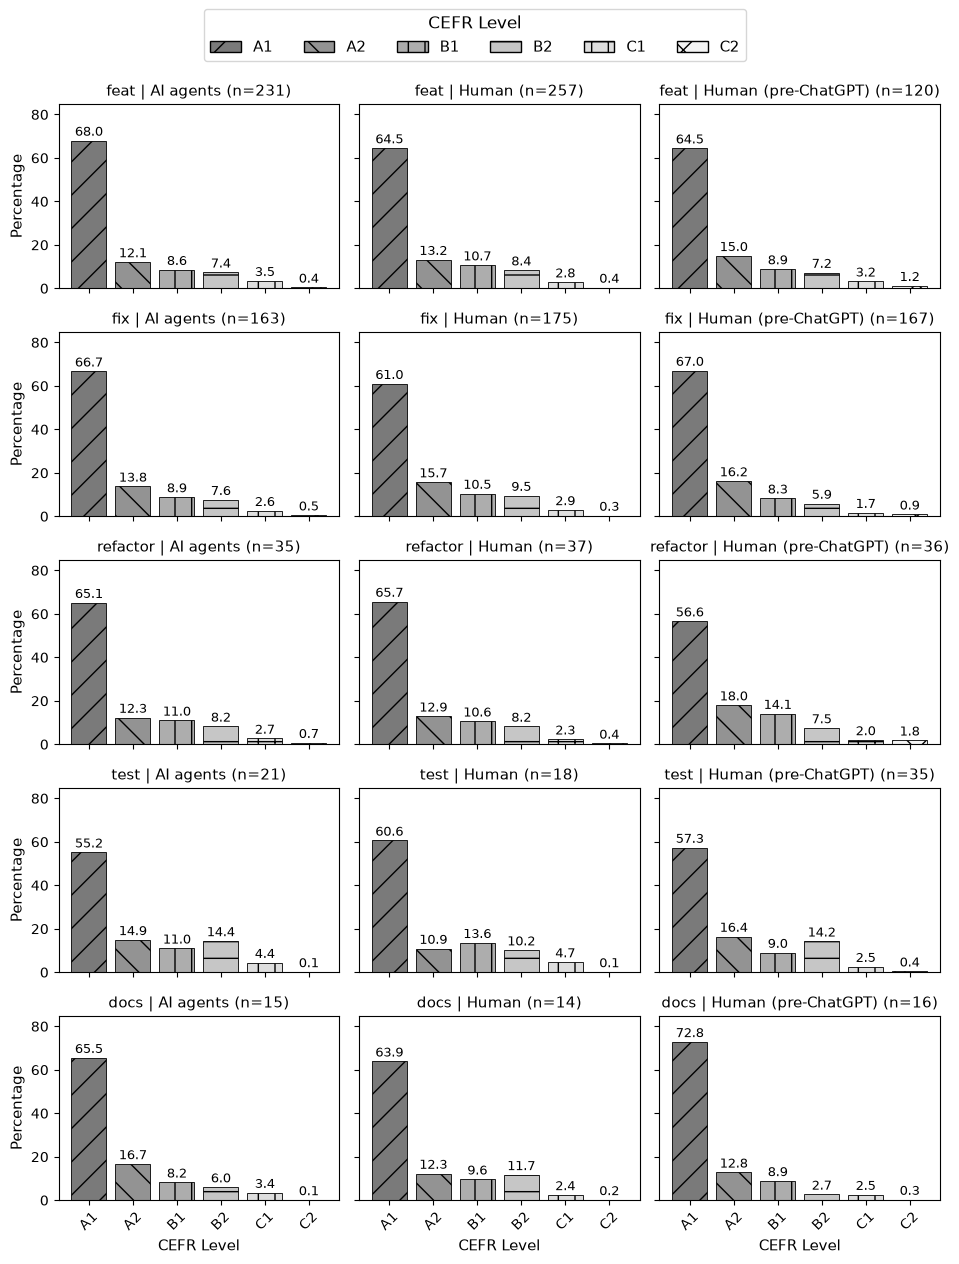

In [21]:
# CEFR construct share per task type (rows) x group (columns), grayscale/hatched like the RQ1 figures.
HATCH = dict(zip(LEVELS, ['/', '\\', '|', '-', '+', 'x']))
GRAYS = dict(zip(LEVELS, ['#7a7a7a', '#939393', '#adadad', '#c6c6c6', '#dedede', '#f4f4f4']))
# Task types with >= MIN_N PRs in every group, most frequent first.
common = [t for t in compact.index if (compact['n PRs'].loc[t].fillna(0) >= MIN_N).all()]
print('task types shown:', common)

lv = df.groupby(['type', 'group'], observed=True)[LEVELS].sum()
lv_pct = lv.div(lv.sum(axis=1), axis=0) * 100
n_prs = df.groupby(['type', 'group'], observed=True).size()

nrow, ncol = len(common), len(GROUPS)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.4 * nrow), sharex=True, sharey=True, squeeze=False)
ytop = min(112, lv_pct.loc[[(t, g) for t in common for g in GROUPS], LEVELS].max().max() + 12)
for r, t in enumerate(common):
    for c, g in enumerate(GROUPS):
        ax = axes[r][c]
        vals = lv_pct.loc[(t, g), LEVELS].values
        bars = ax.bar(range(6), vals, width=0.8, edgecolor='black', linewidth=0.6)
        for l, bar, v in zip(LEVELS, bars, vals):
            bar.set_facecolor(GRAYS[l]); bar.set_hatch(HATCH[l])
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
        ax.set_title(f'{t} | {g} (n={int(n_prs[(t, g)])})', fontsize=11)
        ax.set_ylim(0, ytop)
        ax.set_xticks(range(6)); ax.set_xticklabels(LEVELS, rotation=45, fontsize=10)
        if c == 0: ax.set_ylabel('Percentage', fontsize=11)
        if r == nrow - 1: ax.set_xlabel('CEFR Level', fontsize=11)
handles = [mpatches.Patch(facecolor=GRAYS[l], edgecolor='black', hatch=HATCH[l], label=l) for l in LEVELS]
fig.tight_layout()
fig.legend(handles=handles, title='CEFR Level', loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=6,
           fontsize=11, title_fontsize=12)
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIG_DIR, f'rq3_cefr_by_task_type_group.{ext}'), bbox_inches='tight',
                dpi=200 if ext == 'png' else None)
plt.show()

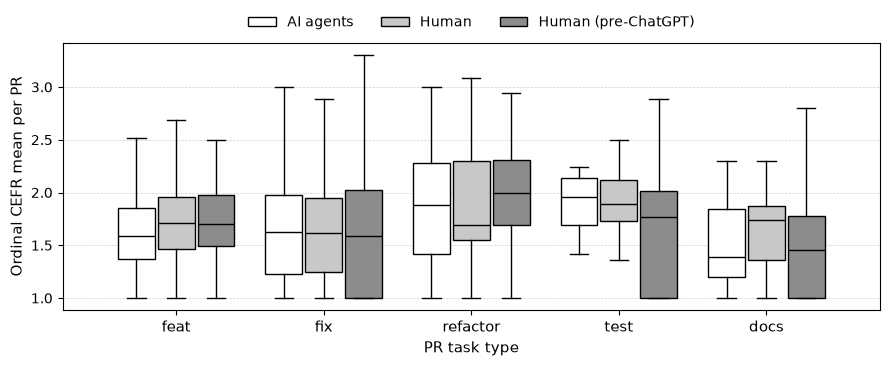

In [22]:
# Per-PR ordinal CEFR mean by task type, one box per group, for the common task types.
fig, ax = plt.subplots(figsize=(9, 3.8))
width, offsets = 0.25, [-0.27, 0.0, 0.27]
face = ['#ffffff', '#c8c8c8', '#8c8c8c']
for i, g in enumerate(GROUPS):
    data = [df[(df['type'] == t) & (df.group == g)]['cefr_mean'].values for t in common]
    bp = ax.boxplot(data, positions=np.arange(len(common)) + offsets[i], widths=width, patch_artist=True,
                    showfliers=False, medianprops=dict(color='black'))
    for b in bp['boxes']:
        b.set_facecolor(face[i]); b.set_edgecolor('black')
ax.set_xticks(range(len(common))); ax.set_xticklabels(common, fontsize=11)
ax.set_ylabel('Ordinal CEFR mean per PR', fontsize=11)
ax.set_xlabel('PR task type', fontsize=11)
ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.6)
ax.legend([mpatches.Patch(facecolor=face[i], edgecolor='black') for i in range(3)], GROUPS, fontsize=10, ncol=3,
          loc='upper center', bbox_to_anchor=(0.5, 1.15), frameon=False)
fig.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIG_DIR, f'rq3_cefr_mean_by_task_type.{ext}'), bbox_inches='tight',
                dpi=200 if ext == 'png' else None)
plt.show()

## 6. LaTeX tables

In [23]:
def to_tex(frame, name, **kw):
    path = os.path.join(TAB_DIR, name + '.tex')
    frame.to_latex(path, **kw)
    print('wrote', os.path.relpath(path, ROOT))

to_tex(dist, 'task_type_distribution', float_format='%.1f')
to_tex(summary_all.T, 'outlier_summary', float_format='%.2f')
to_tex(per_task_all, 'outlier_per_task', float_format='%.1f', na_rep='--')
to_tex(compact, 'task_profile_compact', float_format='%.2f', na_rep='--')
to_tex(kw_task.drop(columns='included'), 'kruskal_task_type', index=False, float_format='%.3f')
to_tex(group_by_task, 'group_within_task_type', index=False, float_format='%.3f')
to_tex(pw_group, 'group_within_task_type_pairwise', index=False, float_format='%.3f')

wrote rq3/tables/task_type_distribution.tex
wrote rq3/tables/outlier_summary.tex
wrote rq3/tables/outlier_per_task.tex
wrote rq3/tables/task_profile_compact.tex
wrote rq3/tables/kruskal_task_type.tex
wrote rq3/tables/group_within_task_type.tex
wrote rq3/tables/group_within_task_type_pairwise.tex


## 7. Notes for updating the paper

* `analysis/rq3_outlier_prs.csv` lists every outlier PR with title and URL for manual inspection.
* New figures (repository root): `rq3_outlier_tasks_agents` (replacement for `action_impact_4.pdf`), `rq3_outlier_tasks_human` (for `action_impact_human.pdf`), `rq3_outlier_tasks_pre_chatgpt`, `rq3_outlier_tasks_all_groups`, `rq3_cefr_by_task_type_group`, `rq3_cefr_mean_by_task_type`.
* The RQ3 results paragraph quotes: the number of outlier PRs, the C1 + C2 range / median / mean, the per-task PR counts and construct totals, and the tasks with the highest mean. All of these are printed in Section 3 above.
* Sections 4a to 4c give the material for extending RQ3 beyond agents: task-type effects within each group, task type versus agent identity, and whether the three groups differ within a task type.